# Лабораторная работа 10 — Датасет Iris в PySpark

In [41]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from itertools import combinations
%matplotlib inline

spark = SparkSession.builder.master('local[*]').appName('iris').getOrCreate()


## 1. Загрузка датасета Iris

In [42]:
df = spark.read.csv('iris.csv', inferSchema=True, header=True)

# Убираем точки из имён колонок
df = df.withColumnRenamed('sepal.length', 'sepal_length') \
       .withColumnRenamed('sepal.width',  'sepal_width') \
       .withColumnRenamed('petal.length', 'petal_length') \
       .withColumnRenamed('petal.width',  'petal_width')

df.show(10)
print('Всего строк:', df.count())
print('Схема:', df.dtypes)

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|variety|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|
|         5.4|        3.9|         1.7|        0.4| Setosa|
|         4.6|        3.4|         1.4|        0.3| Setosa|
|         5.0|        3.4|         1.5|        0.2| Setosa|
|         4.4|        2.9|         1.4|        0.2| Setosa|
|         4.9|        3.1|         1.5|        0.1| Setosa|
+------------+-----------+------------+-----------+-------+
only showing top 10 rows

Всего строк: 150
Схема: [('sepal_length', 'double'), ('sepal_width', 'double'), ('petal_length', 'double'), ('petal_width', 'double'),

## 2. Максимальное, минимальное и среднее значение 4-х параметров для каждого типа цветка

In [43]:
params = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

agg_exprs = []
for p in params:
    agg_exprs += [
        F.max(p).alias(f'max_{p}'),
        F.min(p).alias(f'min_{p}'),
        F.round(F.avg(p), 3).alias(f'avg_{p}')
    ]

stats = df.groupBy('variety').agg(*agg_exprs).orderBy('variety')
stats.show(truncate=False)

+----------+----------------+----------------+----------------+---------------+---------------+---------------+----------------+----------------+----------------+---------------+---------------+---------------+
|variety   |max_sepal_length|min_sepal_length|avg_sepal_length|max_sepal_width|min_sepal_width|avg_sepal_width|max_petal_length|min_petal_length|avg_petal_length|max_petal_width|min_petal_width|avg_petal_width|
+----------+----------------+----------------+----------------+---------------+---------------+---------------+----------------+----------------+----------------+---------------+---------------+---------------+
|Setosa    |5.8             |4.3             |5.006           |4.4            |2.3            |3.428          |1.9             |1.0             |1.462           |0.6            |0.1            |0.246          |
|Versicolor|7.0             |4.9             |5.936           |3.4            |2.0            |2.77           |5.1             |3.0             |4.26       

## 3. Точечные графики (scatter) по каждой паре параметров

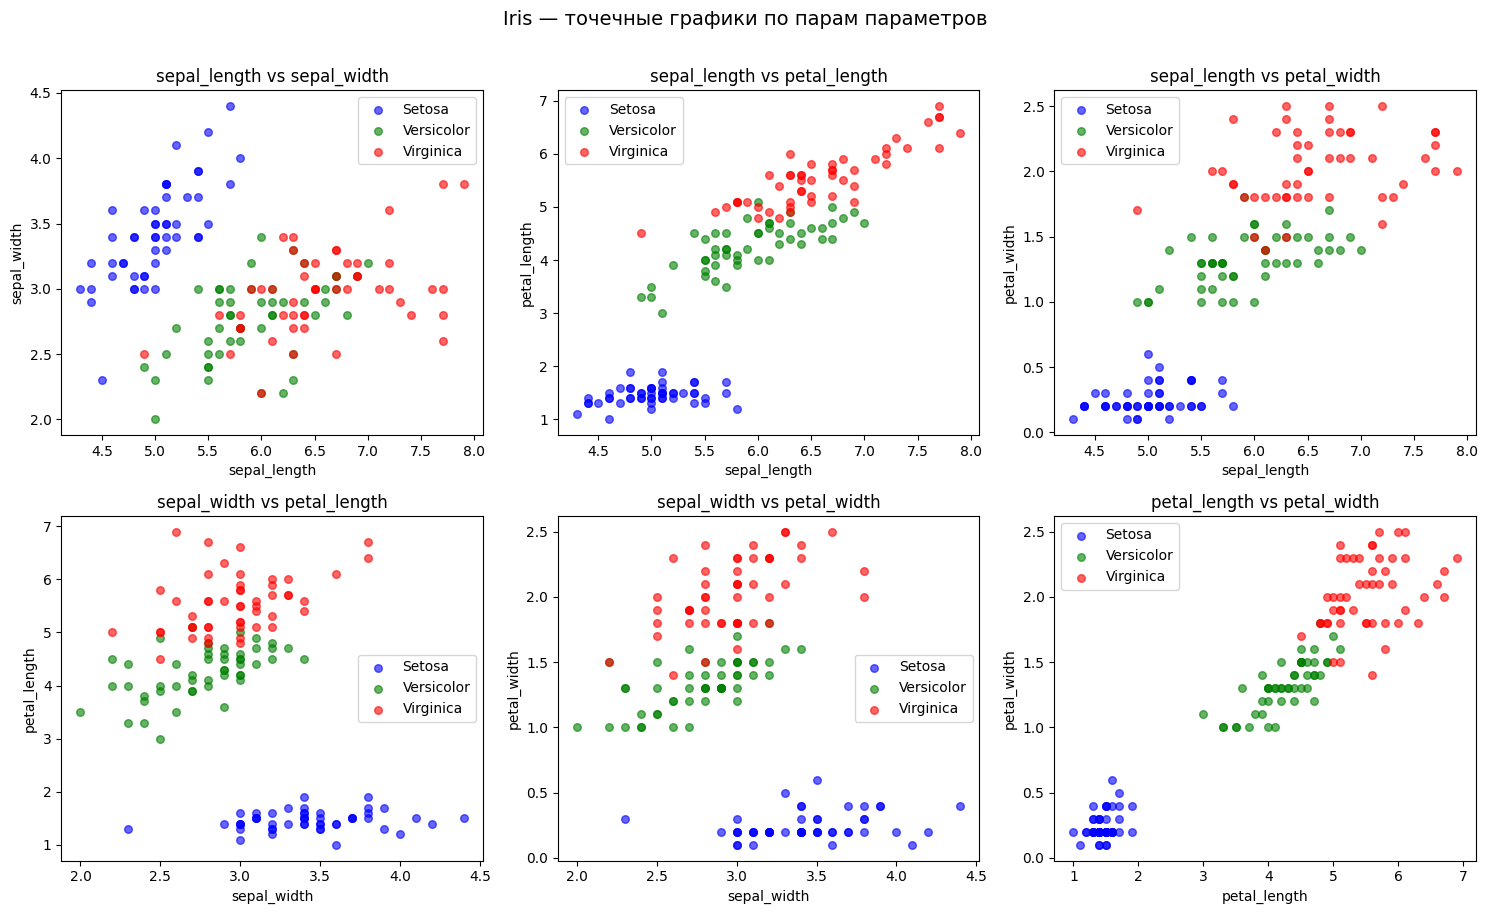

In [44]:
pdf = df.toPandas()
    
colors = {'Setosa': 'blue', 'Versicolor': 'green', 'Virginica': 'red'}
pairs = list(combinations(params, 2))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    for variety, color in colors.items():
        subset = pdf[pdf['variety'] == variety]
        ax.scatter(subset[x_col], subset[y_col], c=color, label=variety, alpha=0.6, s=30)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend()

plt.suptitle('Iris — точечные графики по парам параметров', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('iris_scatter_plots.png', dpi=100)
plt.show()

## 4. Правило разделения цветка Setosa

По графикам хорошо видно, что **Setosa** полностью отделяется от остальных двух видов по длине лепестка (`petal_length`) и ширине лепестка (`petal_width`).

**Правило:**

**ЕСЛИ `petal_length` < 2.5, ТО цветок скорее всего относится к типу Setosa**


## 5. Отдельная колонка с предсказанием

In [45]:
df_pred = df.withColumn(
    'prediction',
    F.when(F.col('petal_length') < 2.5, 'Setosa').otherwise('Not Setosa')
)

df_pred.show(20)

+------------+-----------+------------+-----------+-------+----------+
|sepal_length|sepal_width|petal_length|petal_width|variety|prediction|
+------------+-----------+------------+-----------+-------+----------+
|         5.1|        3.5|         1.4|        0.2| Setosa|    Setosa|
|         4.9|        3.0|         1.4|        0.2| Setosa|    Setosa|
|         4.7|        3.2|         1.3|        0.2| Setosa|    Setosa|
|         4.6|        3.1|         1.5|        0.2| Setosa|    Setosa|
|         5.0|        3.6|         1.4|        0.2| Setosa|    Setosa|
|         5.4|        3.9|         1.7|        0.4| Setosa|    Setosa|
|         4.6|        3.4|         1.4|        0.3| Setosa|    Setosa|
|         5.0|        3.4|         1.5|        0.2| Setosa|    Setosa|
|         4.4|        2.9|         1.4|        0.2| Setosa|    Setosa|
|         4.9|        3.1|         1.5|        0.1| Setosa|    Setosa|
|         5.4|        3.7|         1.5|        0.2| Setosa|    Setosa|
|     

## 6. Оценка качества предсказания

In [46]:
df_eval = df_pred.withColumn(
      'actual_binary',
      F.when(F.col('variety') == 'Setosa', 'Setosa').otherwise('Not Setosa')
  ).withColumn(
      'correct',
      (F.col('prediction') == 'Setosa') == (F.col('variety') == 'Setosa')
)


correct_count   = df_eval.filter(F.col('correct') == True).count()
incorrect_count = df_eval.filter(F.col('correct') == False).count()
total           = df_eval.count()

print(f'Всего записей:       {total}')
print(f'Угадано правильно:   {correct_count}')
print(f'Угадано неправильно: {incorrect_count}')

Всего записей:       150
Угадано правильно:   150
Угадано неправильно: 0


In [47]:
# Матрица ошибок
print('Матрица ошибок (actual_binary vs prediction):')
df_eval.groupBy('actual_binary', 'prediction').count().orderBy('actual_binary', 'prediction').show()

Матрица ошибок (actual_binary vs prediction):
+-------------+----------+-----+
|actual_binary|prediction|count|
+-------------+----------+-----+
|   Not Setosa|Not Setosa|  100|
|       Setosa|    Setosa|   50|
+-------------+----------+-----+

